In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt


C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'C:\Users\Kaustubh Gupta\Downloads\test\PetImages',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    r'C:\Users\Kaustubh Gupta\Downloads\Train\animals',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)


Found 25000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [3]:
cnn = Sequential()

# Convolution Block 1
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
cnn.add(Flatten())

# Fully connected layer
cnn.add(Dense(128, activation='relu'))

# Output layer
cnn.add(Dense(1, activation='sigmoid'))

cnn.summary()


C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [5]:
history = cnn.fit(
    train_generator,
    steps_per_epoch=10,
    epochs=10,
    validation_data=test_generator,
    validation_steps=50
)

Epoch 1/10


C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 59s 6s/step - accuracy: 0.4890 - loss: 0.7530 - val_accuracy: 0.5000 - val_loss: 0.7038
Epoch 2/10
 2/10 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6484 - loss: 0.6563

C:\Users\Kaustubh Gupta\anaconda3\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5691 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5352 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5199 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4932 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5018 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4508 - loss: 0.7057

C:\Users\Kaustubh Gupta\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))


10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4542 - loss: 0.7050 - val_accuracy: 0.5130 - val_loss: 0.6912
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5805 - loss: 0.6907 - val_accuracy: 0.5070 - val_loss: 0.6894
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5470 - loss: 0.6915 - val_accuracy: 0.6720 - val_loss: 0.6851
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5478 - loss: 0.6893 - val_accuracy: 0.6240 - val_loss: 0.6690


In [21]:
history = cnn.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=20,
    validation_data=test_generator,
    validation_steps=50
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 772ms/step - accuracy: 0.7569 - loss: 0.5185 - val_accuracy: 0.8160 - val_loss: 0.4029
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 802ms/step - accuracy: 0.7623 - loss: 0.5070 - val_accuracy: 0.8140 - val_loss: 0.4019
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 700ms/step - accuracy: 0.7592 - loss: 0.5136 - val_accuracy: 0.7380 - val_loss: 0.4880
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 671ms/step - accuracy: 0.7593 - loss: 0.5036 - val_accuracy: 0.8200 - val_loss: 0.4074
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 612ms/step - accuracy: 0.7659 - loss: 0.4923 - val_accuracy: 0.8050 - val_loss: 0.3907
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 517ms/step - accuracy: 0.7787 - loss: 0.4782 - val_accuracy: 0.8430 - val_loss: 0.3969
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 450ms/step - accuracy: 0.7841 - loss: 0.4659 - val_accuracy: 0.8580 - val_loss: 0.3549
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step - accuracy: 0.7716 - loss: 0.4911 - val_accu

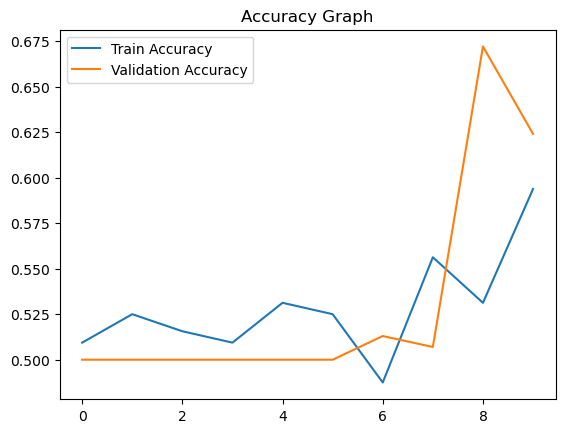

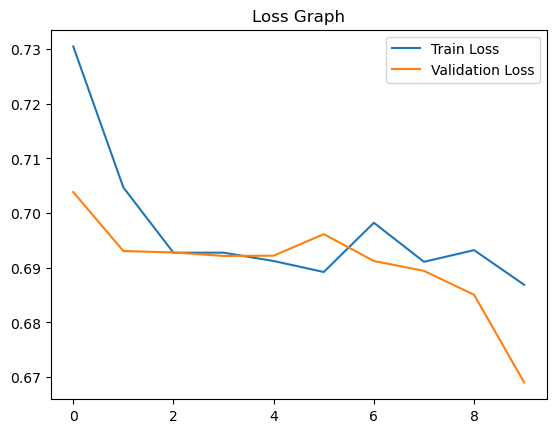

In [6]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()


In [14]:
img_path = r"C:\Users\Kaustubh Gupta\Downloads\test\PetImages\Cat\998.jpg"  

img = image.load_img(img_path, target_size=(64,64))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

result = cnn.predict(img)

print(result)

if result[0][0] > 0.5:
    print("Cat")
else:
    print("Dog")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[0.5231129]]
Cat


In [15]:
img_path = r"C:\Users\Kaustubh Gupta\Downloads\test\PetImages\Dog\9989.jpg"

img = image.load_img(img_path, target_size=(64,64))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

result = cnn.predict(img)

print(result)

if result[0][0] > 0.5:
    print("Cat")
else:
    print("Dog")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.49483633]]
Dog
